In [14]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped, 
    square_input_wave,
    MagneticPhaseSample,
    KrivanekLens, 
    DistortedLens, 
    Biprism,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_jax_scan, evaluate_gaussians_for
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.utils import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.plotting import plot_model, PlotParams

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.filters import clipped
from libertem_holo.base.utils import remove_phase_ramp

In [15]:
def run_model(input_window_width_m=1e-6,
              fringe_spacing=6e-9, # Desired fringe spacing in metres
              num_pixels=1024, # Number of pixels in detector
              voltage_eV=200e3,
              input_object_xy=(0.0, 0.0),
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-1,
              projector_focal_length=5e-3,  # 5 mm
              projector_magnification=-40_000,
              defocus=0.0,
              C12_aberration=0.0,
              C21_aberration=0.0,
              isotropic_distortion=0.0,
              anisotropic_distortion=0.0,
              beam_waist=2e-9,
              overlap_factor = 2.0,
              plot_input_field=False,
              plot_output_field=True,
              plot_output_rays=False,
              plot_ray_diagram=False):

    # Create input field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels
    total_mag = projector_magnification

    input_grid = Detector(
    z=defocus,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    rays_in = square_input_wave(voltage=voltage_eV,
                                aperture_length=input_window_width_m,
                                waist=beam_waist,
                                overlap_factor=overlap_factor,
                                z0=defocus,
                                centre_xy=input_object_xy)
    
    # Make square magnetic sample
    sample = MagneticPhaseSample(
        z=input_grid.z,
        strength=1e-12, # Optical path length shift in metres - adjust to change magnitude
        width=0.1e-6,
        height=0.1e-6,
        x0=0.2e-6 + input_object_xy[0],
        y0=0.05e-6 + input_object_xy[1],
        theta=-0.15,
        modulation_strength=0.002,
        skew_strength=0.01,
        radial_strength=0.5,
        edge_sharpness=1e8,
    )

    rays_after_sample = run_to_end_vmapped(rays_in, (sample,))
    print(f"Number of rays after sample: {len(rays_after_sample.x)}")

    if plot_input_field:
        input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_after_sample, input_grid).block_until_ready()

        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(input_field), extent=input_grid.extent, origin='lower', cmap='inferno')
        axs[0].set_title('Input Field Amplitude')
        axs[1].imshow(np.angle(input_field), extent=input_grid.extent, origin='lower', cmap='twilight')
        axs[1].set_title('Input Field Phase')
        plt.tight_layout()

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    # z3 = object plane distance from projector lens to it's image plane - again it's negative since the image plane is before the lens
    # z4 = distance fromt projector lens to detector
    z3, z4 = calculate_z1_and_z2_from_M_and_f(
        M=projector_magnification,
        f=projector_focal_length,
    )
    z1, z2, z3, z4 = map(abs, (z1, z2, z3, z4))  # Ensure distances are positive

    # Calculate biprism strength needed for desired fringe spacing
    # Biprism is placed halfway between the objective lens focal plane (where the source is)
    # and it's image plane, where the friges will be observed.
    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2 
    a = biprism_z - (z1 + obj_focal_length)
    b = ((z1 + z2) - biprism_z)

    # Quick assert to check distances add up
    L = a + b
    assert L == z1 + z2 - (z1 + obj_focal_length)

    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        C12=C12_aberration,
        C21=C21_aberration,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-11)
    projector_lens = DistortedLens(z=z1+z2+z3, object_plane_dist=z3, focal_length=projector_focal_length,
                                    IsoDist=isotropic_distortion, AnisoDist=anisotropic_distortion)
    detector = Detector(
        z=z1 + z2 + z3 + z4,
        pixel_size=(pixel_size * abs(projector_magnification) / 1.5, pixel_size * abs(projector_magnification) / 1.5),
        shape=(num_pixels, num_pixels),
    )
    extent = detector.extent
    det_xy_coords_1d = detector.coords_1d

    rays_out = run_to_end_vmapped(rays_in, (sample, objective_lens, biprism, projector_lens, detector))
    output_field = evaluate_gaussians_gpu_kernel_wrapper(rays_out, detector).block_until_ready()

    if plot_output_field:
        fig, axs = plt.subplots()
        axs.imshow(np.abs(output_field) ** 2, extent=extent, cmap='gray')
        axs.set_title('Hologram Intensity')
        plt.tight_layout()
    if plot_output_rays:
        axs.plot(rays_out.x, rays_out.y, 'r.', markersize=0.5, alpha=0.1)


    if plot_ray_diagram:
        plot_model(
            components=[sample, objective_lens, biprism, projector_lens, detector],
            rays=rays_in[::10000],
            plot_params=PlotParams(
                figsize=(10, 6),
            ),
        )

    return output_field, extent, det_xy_coords_1d

Number of rays after sample: 251001


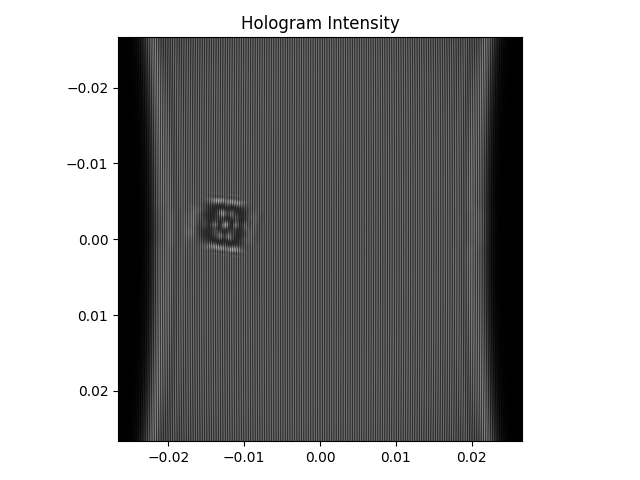

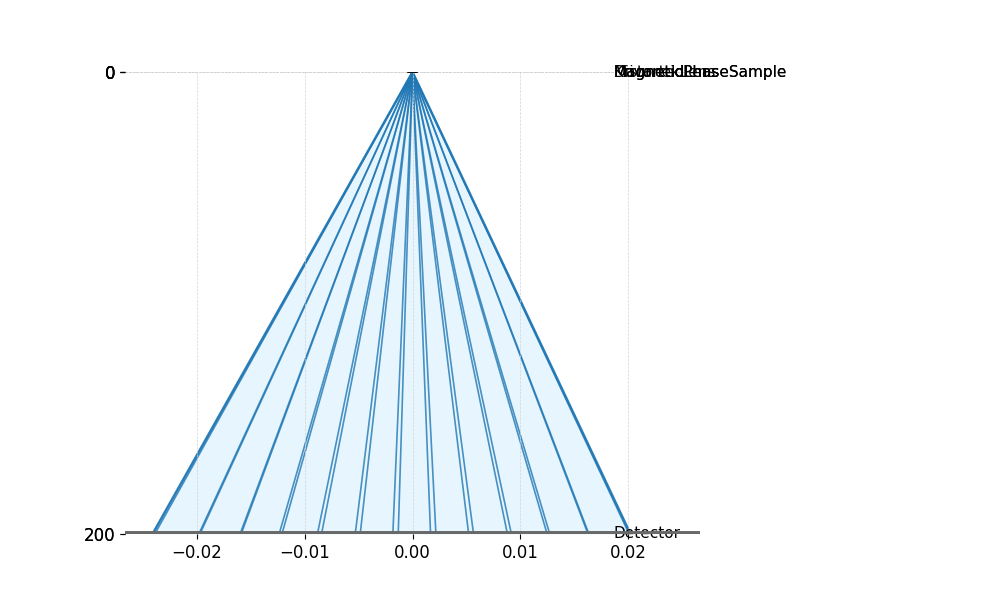

In [36]:
output_field, extent, det_xy_coords_1d = run_model(
    input_window_width_m=2e-6,
    fringe_spacing=6e-9,
    num_pixels=1024,
    beam_waist=8e-9,
    input_object_xy=(0e-7, 0e-7),
    obj_magnification=-1,
    C12_aberration=1e-4,  # Astigmatism
    C21_aberration=5e-5,  # Coma
    isotropic_distortion=2e12,
    anisotropic_distortion=0,
    plot_input_field=False,
    plot_output_field=True,
    plot_output_rays=False,
    plot_ray_diagram=True,
)

Detected 201 peaks. Mean fringe spacing = 2.331e-04 m (std 2.601e-05)


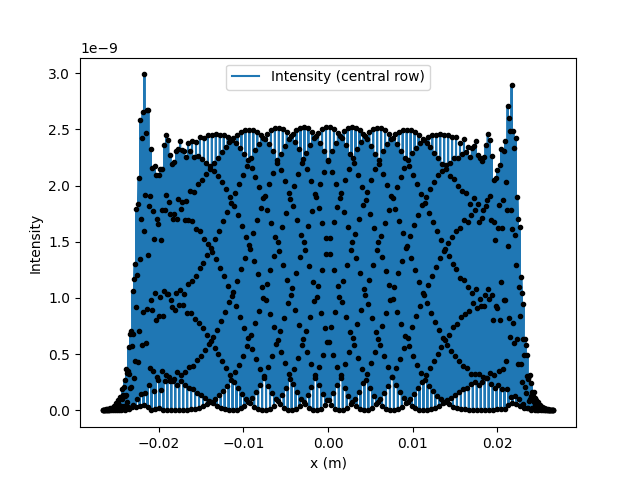

In [37]:
# measure fringe spacing from central row of E_out
x = det_xy_coords_1d[0]
intensity = np.abs(output_field[128 // 2, :])**2
intensity = np.array(intensity)

# peak detection: local maxima above threshold (try 20% of max, then 5% if too few)
th = intensity.max() * 0.20
peaks = np.where((intensity[1:-1] > intensity[:-2]) & (intensity[1:-1] > intensity[2:]) & (intensity[1:-1] > th))[0] + 1
if len(peaks) < 2:
    th = intensity.max() * 0.05
    peaks = np.where((intensity[1:-1] > intensity[:-2]) & (intensity[1:-1] > intensity[2:]) & (intensity[1:-1] > th))[0] + 1

if len(peaks) >= 2:
    spacings = np.diff(x[peaks])
    mean_spacing = spacings.mean()
    std_spacing = spacings.std()
    print(f"Detected {len(peaks)} peaks. Mean fringe spacing = {mean_spacing:.3e} m (std {std_spacing:.3e})")
else:
    print("Could not detect enough peaks to measure spacing.")

# plot with detected peaks
plt.figure()
plt.plot(x, intensity, label='Intensity (central row)')
plt.plot(x, intensity, 'k.')
plt.xlabel('x (m)')
plt.ylabel('Intensity')
plt.legend()



In [38]:
holo = np.abs(output_field) ** 2 
out_shape = (1024, 1024)
holo_params = HoloParams.from_hologram(
    hologram=holo, central_band_mask_radius=20, 
    out_shape=out_shape, line_filter_width=0, xp=np, circle_filter_order=100,
)
print(holo_params.sb_position)
slice_fft = get_slice_fft(sig_shape=holo.shape, out_shape=out_shape)

wave_obj = reconstruct_frame(
    frame=holo, sb_pos=holo_params.sb_position, 
    slice_fft=slice_fft, aperture=holo_params.aperture, xp=np,
)

phase_t, _, _ = remove_phase_ramp(np.angle(wave_obj))

(1023.0, 795.0)


Text(0.5, 1.0, 'Reconstructed Phase (unwrapped)')

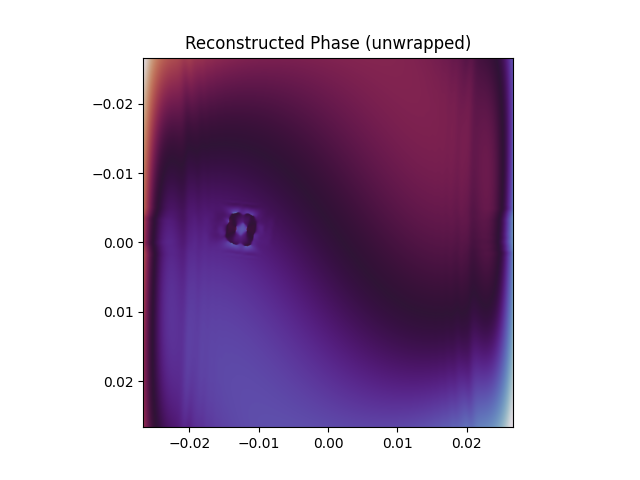

In [39]:
plt.figure()
plt.imshow(phase_unwrap(phase_t), cmap='twilight', extent=extent)
plt.title('Reconstructed Phase (unwrapped)')

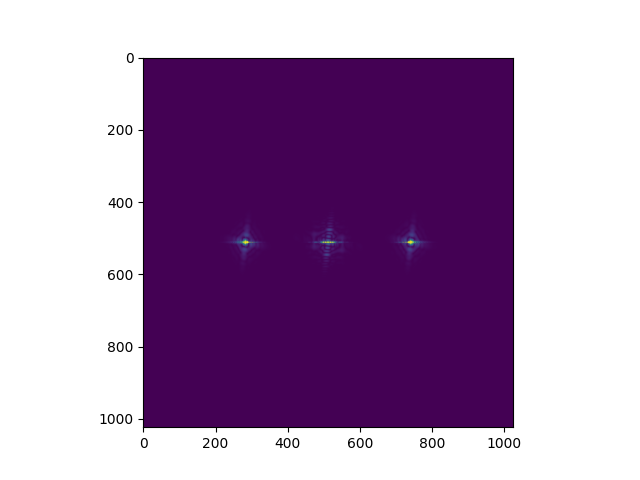

In [40]:
fft = np.fft.fftshift(np.fft.fft2(holo))
img = np.abs(fft)
plt.figure()
plt.imshow(img, vmin=np.min(clipped(img)), vmax=np.max(clipped(img)))